In [ ]:
import kagglehub
path = kagglehub.dataset_download("ahmedmohamed2003/retail-store-sales-dirty-for-data-cleaning")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'retail-store-sales-dirty-for-data-cleaning' dataset.
Path to dataset files: /kaggle/input/retail-store-sales-dirty-for-data-cleaning


### Which features (Price, Quantity, or Category) have the strongest correlation with Total Spent?

### Does the Location (Online vs. In-Store) significantly impact the average transaction value?

### How does the application of a discount affect customer purchasing behavior and overall revenue?

In [ ]:
import os
os.listdir(path)

['retail_store_sales.csv']

In [ ]:
import pandas as pd

file_path = os.path.join(path, 'retail_store_sales.csv')
df = pd.read_csv(file_path)

df.head()

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,NaN
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False


In [ ]:
df.shape

(12575, 11)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12575 entries, 0 to 12574
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    12575 non-null  object 
 1   Customer ID       12575 non-null  object 
 2   Category          12575 non-null  object 
 3   Item              11362 non-null  object 
 4   Price Per Unit    11966 non-null  float64
 5   Quantity          11971 non-null  float64
 6   Total Spent       11971 non-null  float64
 7   Payment Method    12575 non-null  object 
 8   Location          12575 non-null  object 
 9   Transaction Date  12575 non-null  object 
 10  Discount Applied  8376 non-null   object 
dtypes: float64(3), object(8)
memory usage: 1.1+ MB


In [ ]:
df.isnull().sum()

,0
Transaction ID,0
Customer ID,0
Category,0
Item,1213
Price Per Unit,609
Quantity,604
Total Spent,604
Payment Method,0
Location,0
Transaction Date,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.describe()

,Price Per Unit,Quantity,Total Spent
count,11966.000000,11971.000000,11971.000000
mean,23.365912,5.536380,129.652577
std,10.743519,2.857883,94.750697
min,5.000000,1.000000,5.000000
25%,14.000000,3.000000,51.000000
50%,23.000000,6.000000,108.500000
75%,33.500000,8.000000,192.000000
max,41.000000,10.000000,410.000000


In [ ]:
df_cleancopy = df.copy()

In [ ]:
import pandas as pd
df_cleancopy['Transaction Date'] = pd.to_datetime(df_cleancopy['Transaction Date'],errors = 'coerce')

In [ ]:
df_cleancopy['Year'] = df_cleancopy['Transaction Date'].dt.year

In [ ]:
df_cleancopy['Month'] = df_cleancopy['Transaction Date'].dt.month

In [ ]:
df_cleancopy.dtypes

,0
Transaction ID,object
Customer ID,object
Category,object
Item,object
Price Per Unit,float64
Quantity,float64
Total Spent,float64
Payment Method,object
Location,object
Transaction Date,datetime64[ns]


In [ ]:
df_cleancopy['Price Per Unit'] = df_cleancopy['Price Per Unit'].fillna(df_cleancopy['Price Per Unit'].mean())

In [ ]:
df_cleancopy['Quantity'] = df_cleancopy['Quantity'].fillna(df_cleancopy['Quantity'].mean())

In [ ]:
df_cleancopy['Total Spent'] = df_cleancopy['Price Per Unit'] * df_cleancopy['Quantity']

In [ ]:
df_cleancopy['Item'] = df_cleancopy['Item'].fillna('Unknown')

In [ ]:
df_cleancopy['Discount Applied'].value_counts()

,count
Discount Applied,
True,4219
False,4157


In [ ]:
df_cleancopy.isnull().sum()

,0
Transaction ID,0
Customer ID,0
Category,0
Item,0
Price Per Unit,0
Quantity,0
Total Spent,0
Payment Method,0
Location,0
Transaction Date,0


In [ ]:
df_cleancopy[df_cleancopy['Total Spent'].isnull()].head()

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied,Year,Month


In [ ]:
df_cleancopy[df_cleancopy["Total Spent"].isnull()][["Price Per Unit", "Quantity"]].head()

,Price Per Unit,Quantity


In [ ]:
df_cleancopy[['Total Spent']].head()

,Total Spent
0,185.0
1,261.0
2,43.0
3,247.5
4,87.5


In [ ]:
df_cleancopy.head()

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied,Year,Month
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True,2024,4
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True,2023,7
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False,2022,10
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,NaN,2022,5
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False,2022,10


In [ ]:
df_cleancopy['Quantity'] = df_cleancopy['Quantity'].round().astype(int)

In [ ]:
df_cleancopy['Total Spent'] = df_cleancopy['Price Per Unit'] * df_cleancopy['Quantity']

In [ ]:
df_cleancopy.isnull().sum()

,0
Transaction ID,0
Customer ID,0
Category,0
Item,0
Price Per Unit,0
Quantity,0
Total Spent,0
Payment Method,0
Location,0
Transaction Date,0


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

**Univariate analysis**

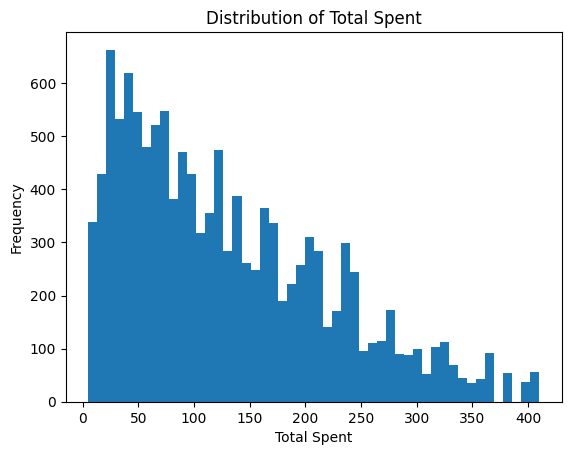

In [ ]:
plt.hist(df_cleancopy['Total Spent'], bins=50)
plt.title('Distribution of Total Spent')
plt.xlabel('Total Spent')
plt.ylabel('Frequency')
plt.show()

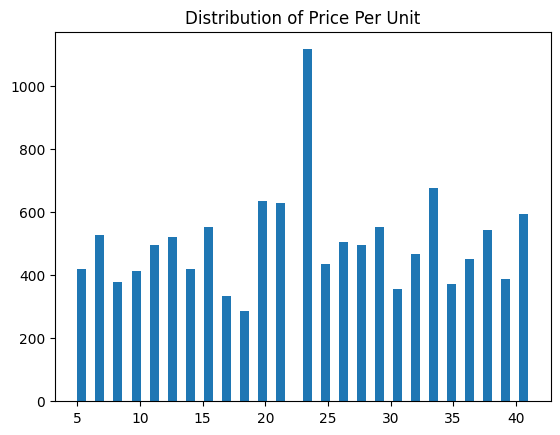

In [ ]:
plt.hist(df_cleancopy['Price Per Unit'], bins=50)
plt.title('Distribution of Price Per Unit')
plt.show()

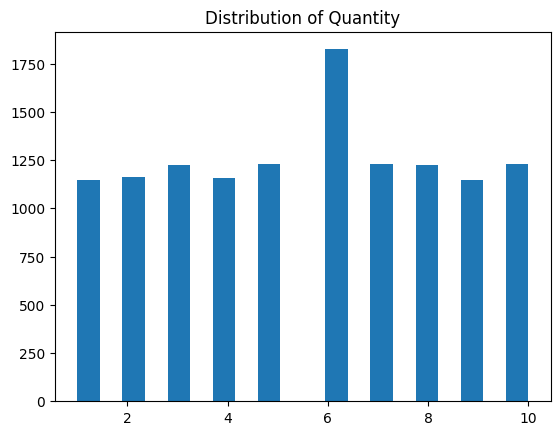

In [ ]:
plt.hist(df_cleancopy['Quantity'], bins=20)
plt.title('Distribution of Quantity')
plt.show()

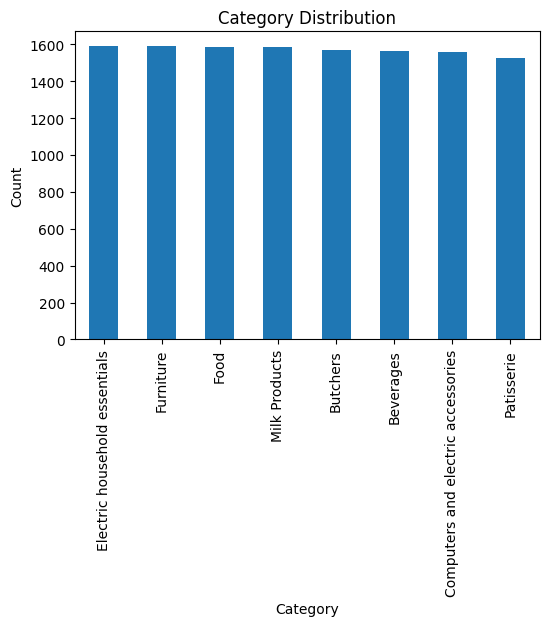

In [ ]:
plt.figure(figsize=(6,4))
df_cleancopy['Category'].value_counts().plot(kind='bar')
plt.title('Category Distribution')
plt.xlabel('Category')
plt.ylabel('Count')
plt.show()

In [ ]:
df['Category'].value_counts()

,count
Category,
Electric household essentials,1591
Furniture,1591
Food,1588
Milk Products,1584
Butchers,1568
Beverages,1567
Computers and electric accessories,1558
Patisserie,1528


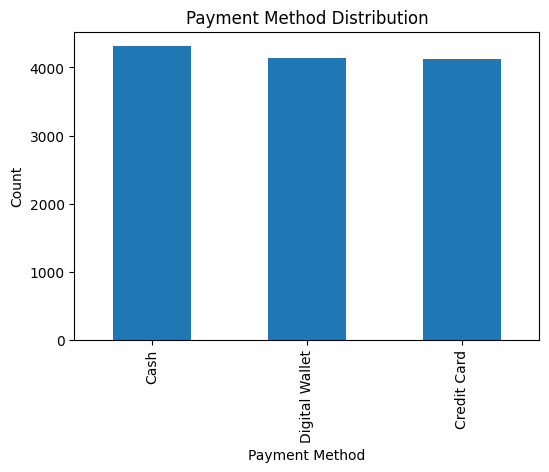

In [ ]:
plt.figure(figsize=(6,4))
df_cleancopy['Payment Method'].value_counts().plot(kind='bar')
plt.title('Payment Method Distribution')
plt.xlabel('Payment Method')
plt.ylabel('Count')
plt.show()

In [ ]:
df['Payment Method'].value_counts()

,count
Payment Method,
Cash,4310
Digital Wallet,4144
Credit Card,4121


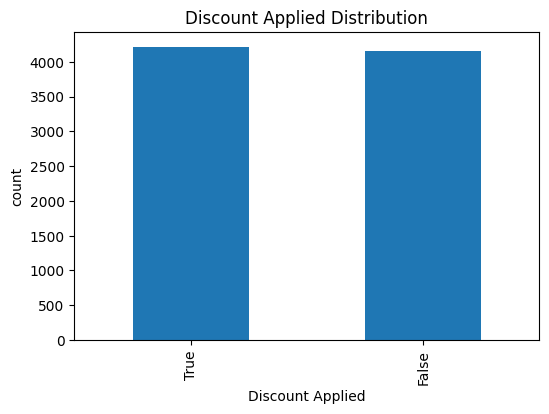

In [ ]:
plt.figure(figsize=(6,4))
df_cleancopy['Discount Applied'].value_counts().plot(kind='bar')
plt.title('Discount Applied Distribution')
plt.xlabel('Discount Applied')
plt.ylabel('count')
plt.show()

In [ ]:
df_cleancopy['Discount Applied'] = df_cleancopy['Discount Applied'].fillna(False)

/tmp/ipykernel_191/2047797613.py:1: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



In [ ]:
df_cleancopy['Discount Applied'].dtype

dtype('bool')

In [ ]:
df_cleancopy['Discount Applied'].isna().sum()

np.int64(0)

In [ ]:
df_cleancopy['Discount Applied'].unique()

array([ True, False])

In [ ]:
df_cleancopy['Discount Applied'].apply(type).unique()

array([<class 'bool'>], dtype=object)

In [ ]:
df['Discount Applied'].value_counts(dropna=False)

,count
Discount Applied,
True,4219
NaN,4199
False,4157


In [ ]:
df_cleancopy['Discount Applied'].value_counts()

,count
Discount Applied,
False,8356
True,4219


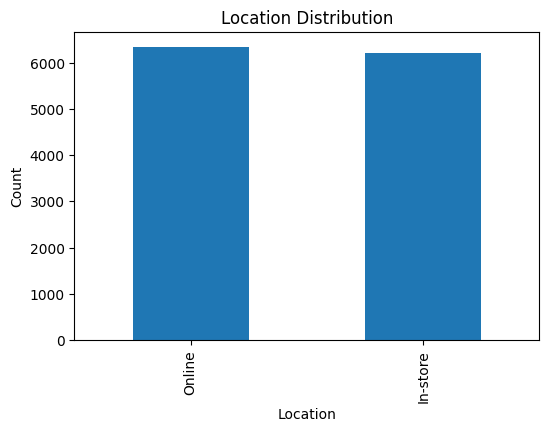

In [ ]:
plt.figure(figsize=(6,4))
df_cleancopy['Location'].value_counts().head(10).plot(kind='bar')
plt.title('Location Distribution')
plt.xlabel('Location')
plt.ylabel('Count')
plt.show()

In [ ]:
df_cleancopy['Location'].value_counts()

,count
Location,
Online,6354
In-store,6221


**Bivariate analysis**

In [ ]:
import plotly.express as px

fig = px.scatter(df_cleancopy,x="Quantity",y="Total Spent",title="Quantity vs Total Spent")
fig.show()

In [ ]:
fig = px.scatter(df_cleancopy , x='Price Per Unit', y='Total Spent', title = 'Price per unit vs total spent')
fig.show()

In [ ]:
fig = px.box(df_cleancopy , x='Discount Applied',y='Total Spent', title = 'Discount applied vs total spent')
fig.show()

In [ ]:
df_cleancopy.groupby("Discount Applied")["Total Spent"].mean()

,Total Spent
Discount Applied,
False,129.694830
True,131.240777


In [ ]:
fig = px.bar(df_cleancopy , x='Location',y='Total Spent', title = 'Location vs total spent')
fig.show()

In [ ]:
df_cleancopy.groupby('Location')['Total Spent'].mean()

,Total Spent
Location,
In-store,129.502410
Online,130.909718


In [ ]:
avg_loc = df_cleancopy.groupby('Location')['Total Spent'].mean().reset_index()
fig = px.bar(avg_loc,x='Location',y='Total Spent',title='Average Transaction Value by Location')
fig.show()

In [ ]:
fig = px.box(df_cleancopy,x="Location",y="Total Spent",title="Distribution of Total Spending")
fig.show()

In [ ]:
df_cleancopy.groupby("Category")["Total Spent"].sum().sort_values(ascending=False)

,Total Spent
Category,
Butchers,217555.073876
Electric household essentials,213552.255641
Beverages,206758.010112
Food,205853.051228
Furniture,205462.680553
Computers and electric accessories,202514.501170
Patisserie,194697.110229
Milk Products,191042.160287


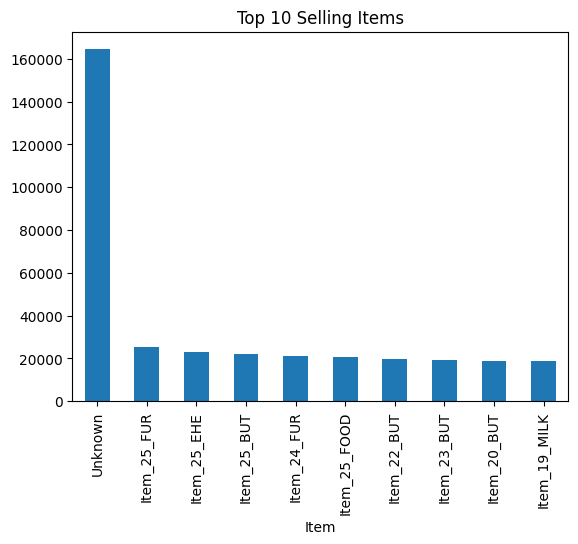

In [ ]:
top_items = df_cleancopy.groupby('Item')['Total Spent'].sum().sort_values(ascending=False).head(10).plot(kind='bar')
plt.title('Top 10 Selling Items')
plt.show()

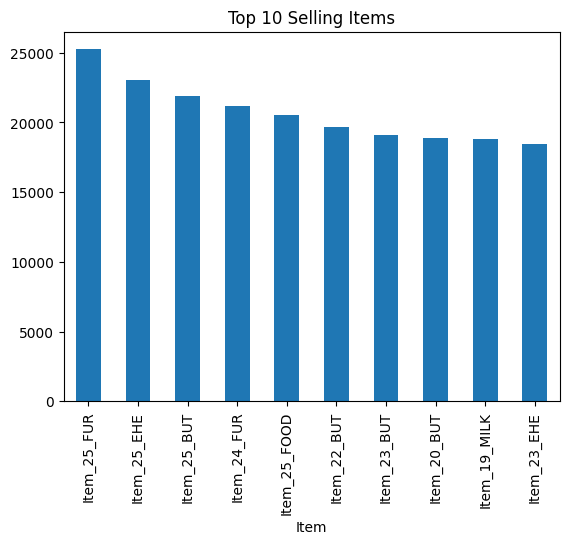

In [ ]:
df_items = df_cleancopy[df_cleancopy['Item'] != 'Unknown']
df_items.groupby('Item')['Total Spent'].sum().sort_values(ascending=False).head(10).plot(kind='bar')
plt.title('Top 10 Selling Items')
plt.show()

**Multivariate analysis**

In [ ]:
fig = px.box(df_cleancopy , x ='Location',y ='Total Spent',color='Discount Applied',title = 'Total spent by location and discount applied')
fig.show()

In [ ]:
cat_loc = df_cleancopy.groupby(['Category','Location'])['Total Spent'].sum().reset_index()
fig = px.bar(cat_loc,x='Category',y='Total Spent',color='Location',barmode ='group',title='Total spent by category and location')
fig.show()

In [ ]:
fig = px.scatter(df_cleancopy, x = 'Quantity',y='Total Spent',color='Location',title= 'Price vs Quantity by location')
fig.show()

In [ ]:
df_cleancopy["Location"].value_counts()

,count
Location,
Online,6354
In-store,6221


In [ ]:
fig = px.scatter(df_cleancopy.sample(1000),x='Price Per Unit',y='Quantity',color='Location',title='Price vs Quantity by Channel (Sampled)')
fig.show()

In [ ]:
df_cleancopy[['Price Per Unit', 'Quantity']].corr()

,Price Per Unit,Quantity
Price Per Unit,1.000000,0.011308
Quantity,0.011308,1.000000


In [ ]:
df_cleancopy[['Price Per Unit','Quantity','Total Spent']].corr()

,Price Per Unit,Quantity,Total Spent
Price Per Unit,1.000000,0.011308,0.633850
Quantity,0.011308,1.000000,0.713448
Total Spent,0.633850,0.713448,1.000000


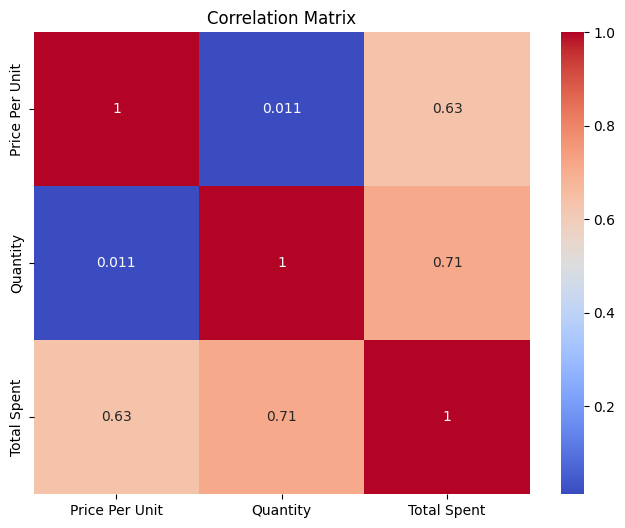

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(df_cleancopy[['Price Per Unit', 'Quantity', 'Total Spent']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

<Axes: xlabel='DayOfWeek'>

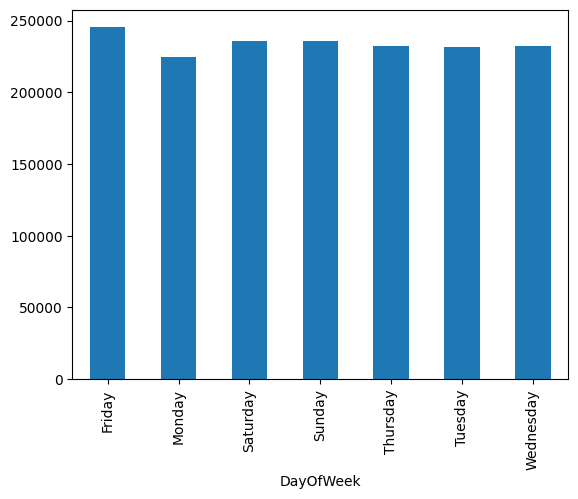

In [ ]:
df_cleancopy['DayOfWeek'] = df_cleancopy['Transaction Date'].dt.day_name()
df_cleancopy.groupby('DayOfWeek')['Total Spent'].sum().plot(kind='bar')

**The dataset was fully preprocessed by encoding categorical variables using one-hot encoding and standardizing numerical features using StandardScaler. Although no predictive modeling was performed, preprocessing was conducted to demonstrate readiness for machine learning applications and to improve analytical consistency.
The Item variable was excluded from encoding due to its high cardinality and limited analytical value, and identifiers such as Transaction ID and Customer ID were removed.**

In [ ]:
df_cleancopy= df_cleancopy.drop(columns=['Transaction Date'])

In [ ]:
df_cleancopy = pd.get_dummies(df_cleancopy,columns=['Category', 'Payment Method', 'Location', 'DayOfWeek'],drop_first=True)

In [ ]:
df_cleancopy.head()

,Transaction ID,Customer ID,Item,Price Per Unit,Quantity,Total Spent,Discount Applied,Year,Month,Category_Butchers,...,Category_Patisserie,Payment Method_Credit Card,Payment Method_Digital Wallet,Location_Online,DayOfWeek_Monday,DayOfWeek_Saturday,DayOfWeek_Sunday,DayOfWeek_Thursday,DayOfWeek_Tuesday,DayOfWeek_Wednesday
0,TXN_6867343,CUST_09,Item_10_PAT,18.5,10,185.0,True,2024,4,False,...,True,False,True,True,True,False,False,False,False,False
1,TXN_3731986,CUST_22,Item_17_MILK,29.0,9,261.0,True,2023,7,False,...,False,False,True,True,False,False,True,False,False,False
2,TXN_9303719,CUST_02,Item_12_BUT,21.5,2,43.0,False,2022,10,True,...,False,True,False,True,False,False,False,False,False,True
3,TXN_9458126,CUST_06,Item_16_BEV,27.5,9,247.5,False,2022,5,False,...,False,True,False,True,False,True,False,False,False,False
4,TXN_4575373,CUST_05,Item_6_FOOD,12.5,7,87.5,False,2022,10,False,...,False,False,True,True,False,False,True,False,False,False


In [ ]:
df_cleancopy = df_cleancopy.drop(columns=['Transaction ID', 'Customer ID', 'Item'])

In [ ]:
df_cleancopy.head()

,Price Per Unit,Quantity,Total Spent,Discount Applied,Year,Month,Category_Butchers,Category_Computers and electric accessories,Category_Electric household essentials,Category_Food,...,Category_Patisserie,Payment Method_Credit Card,Payment Method_Digital Wallet,Location_Online,DayOfWeek_Monday,DayOfWeek_Saturday,DayOfWeek_Sunday,DayOfWeek_Thursday,DayOfWeek_Tuesday,DayOfWeek_Wednesday
0,18.5,10,185.0,True,2024,4,False,False,False,False,...,True,False,True,True,True,False,False,False,False,False
1,29.0,9,261.0,True,2023,7,False,False,False,False,...,False,False,True,True,False,False,True,False,False,False
2,21.5,2,43.0,False,2022,10,True,False,False,False,...,False,True,False,True,False,False,False,False,False,True
3,27.5,9,247.5,False,2022,5,False,False,False,False,...,False,True,False,True,False,True,False,False,False,False
4,12.5,7,87.5,False,2022,10,False,False,False,True,...,False,False,True,True,False,False,True,False,False,False


In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
num_cols = ['Price Per Unit', 'Quantity', 'Total Spent', 'Year', 'Month']
df_cleancopy[num_cols] = scaler.fit_transform(df_cleancopy[num_cols])

**Data cleaning summary**
* Converted transaction date from object to datetime.
* Handled missing values:
1. Replaced missing values in Quantity with column mean.
2. Replaced missing values of Price Per Unit values with column mean.
3. Replaced missing Item values with 'Unknown'.
* Recalculated Total spent = Quantity * Price Per Unit.
* Created new features using datetime (Year,Month and DayOfWeek).
* Converted discount applied into a boolean variable.
* Removed identifiers(TransactionID,CustomerID,Items) since they do not provide analytical value.
* Encoded categorical variable using one-hot encoding.













**The analysis of the retail transaction dataset revealed a business environment where revenue is primarily driven by transaction volume and specific product categories rather than promotional strategies. By investigating eight distinct variables through univariate and multivariate lenses, we established that Quantity is the most significant lever for total revenue, maintaining a stronger relationship with spending than the price per unit. This suggests that the store's financial health is more dependent on encouraging customers to build larger baskets rather than increasing the cost of individual items.When examining the sales channels, a clear performance gap emerged between online and physical locations. Online transactions consistently outperformed in-store purchases in both mean and median revenue, showing higher stability and fewer outliers. However, the physical store remains vital for specific segments; for instance, "Furniture" and "Patisserie" are the only categories where in-store performance rivals or exceeds digital sales. This indicates that while the digital storefront is the primary revenue engine, customers still value the physical experience for high-touch or perishable goods.Surprisingly, the data suggests that current discounting strategies are not significantly impacting the total amount spent per customer. The statistical comparison showed that transactions with discounts applied resulted in nearly identical spending patterns to those without, implying that customers are purchasing based on necessity or brand loyalty rather than price incentives. Furthermore, while revenue is distributed fairly evenly across the week, the slight peak on Fridays and the dip on Mondays suggest that the business should align its marketing efforts and inventory restocking with these weekend-adjacent surges.This project successfully transitioned from raw, "dirty" data—handling missing values and incorrect data types—to a fully preprocessed, machine-learning-ready state. The use of standard scaling and one-hot encoding ensures that the numerical insights gathered are consistent and that the dataset is prepared for future predictive modeling to further optimize these retail operations.**